In [1]:
# R script for phyloGWAS
# author: Sheng-Kai Hsu
# date created: 2023.06.16
# data last edited: 2023.09.12


In [2]:
rm(list=ls())
library(limma)
library(ape)
library(parallel)
library(pheatmap)
library(BGLR)

In [3]:
source("/workdir/sh2246/p_evolBNI/src/S01_phyloK.R")

In [142]:
# load phenotypic data
pMatrix = read.csv("/workdir/hackathon_202309/data/ePCs.09.14.23.csv",header = T,row.names = 1)
trait = data.frame(sample = rownames(pMatrix),trait = pMatrix$ePC_1)
rownames(trait) = trait[,1]

In [54]:
# load K
K = read.table("/workdir/hackathon_202309/output/Kphylo.txt")
colnames(K) = rownames(K)

In [143]:
common_row = Reduce(intersect,list(rownames(trait),rownames(K)))
trait_filtered = trait[common_row,]
K_filtered = K[common_row,common_row]


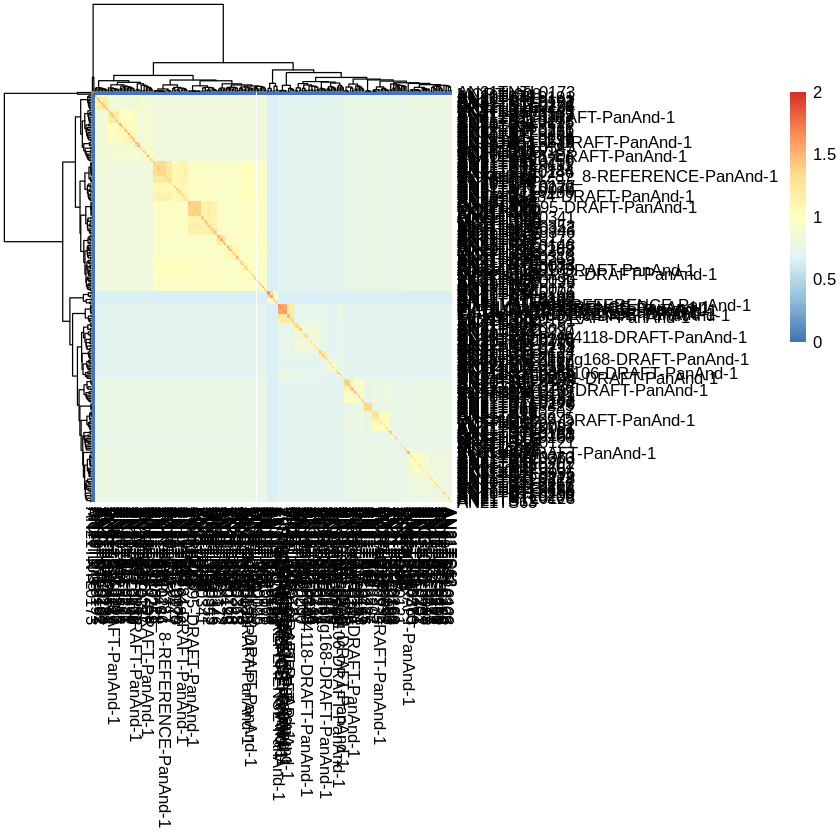

In [144]:
pheatmap(K_filtered)

In [145]:
ModelI = BGLR(trait_filtered[,2],response_type= "gaussian",nIter = 1e5,burnIn = 5e3,verbose = F,thin = 5,
               ETA=list(Kn=list(K =data.matrix(K_filtered),model="RKHS")))

In [146]:
vae.baseline = (ModelI$ETA$K$varU)/(ModelI$ETA$K$varU+ModelI$varE)

In [147]:
vae.baseline

[1] 0.7828937

In [97]:
ModelI$fit$

[1] 1.331285

In [10]:
# # construct NJ phylogeny from alignment
aln_flist = list.files("/workdir/hackathon_202309/output/MSAs_gs", pattern = "*.fa$",full.names = T)
aln_list = mclapply(aln_flist,function(x) read.FASTA(x),mc.cores = 40)
aln_ID = substr(strsplit2(aln_flist,"/")[,ncol(strsplit2(aln_flist,"/"))],1,20)
names(aln_list) = aln_ID

In [26]:
dlist = mclapply(aln_list,function(x) dist.dna(x,pairwise.deletion = T,as.matrix = T,model = "TN93",gamma = T),
                 mc.cores = 5)
njtree.list = mclapply(dlist,function(x) njs(x),mc.cores = 5)

In [60]:
njtree.list.filtered = njtree.list[sapply(njtree.list,function(x) any(grepl("MCRTL028",x$tip.label)))]


In [61]:
njtree.list.renamed = mclapply(njtree.list.filtered,function(x) {
    x.renamed = keep.tip(x,tip = intersect(nTre.rooted$tip.label,x$tip.label))
    x.renamed = root(x.renamed,"MCRTL028")
    return(x.renamed)
},mc.cores = 30)

In [ ]:
K.gene.ML.list = mclapply(njtree.list.renamed,function(x) phyloK(x),mc.cores =30)

In [74]:
K.gene.ML.list2 = mclapply(K.gene.ML.list,function(x) {
    tmp = x
    overlap = intersect(rownames(K_filtered),rownames(x))
    tmp = tmp[overlap,overlap]
    missTaxa = setdiff(rownames(K_filtered),rownames(tmp))
    tmp = cbind(tmp,matrix(rep(0,nrow(tmp)*length(missTaxa)),nrow = nrow(tmp),ncol = length(missTaxa)))
    tmp = rbind(tmp,matrix(rep(0,ncol(tmp)*length(missTaxa)),ncol = ncol(tmp),nrow = length(missTaxa)))
    rownames(tmp)[-(1:nrow(x))] = missTaxa
    colnames(tmp)[-(1:ncol(x))] = missTaxa
    return(tmp)
},mc.cores = 30)

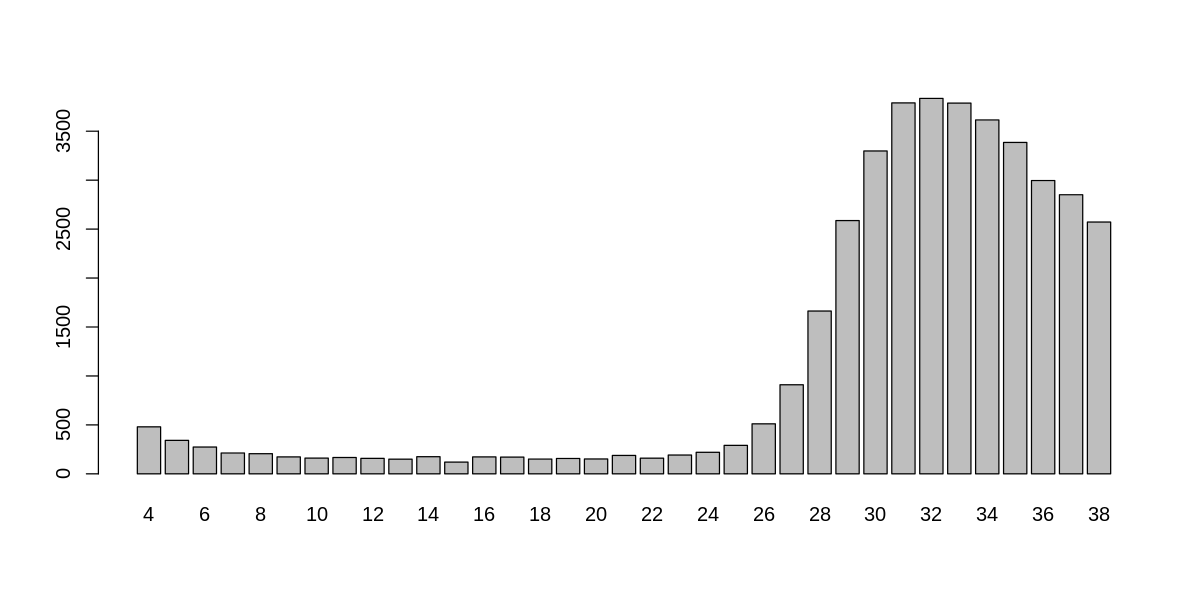

In [199]:
# load ML gene tree 
# gTre.flist = list.files("/workdir/sh2246/p_evolBNI/output/geneTree/",pattern = "*bestTree*",full.names = "T")
# gTre.list = mclapply(gTre.flist,function(x) read.tree(x),mc.cores = 40)
# names(gTre.list) = substr(strsplit2(gTre.flist,"/")[,8],16,31)                    
# gTre.renamed = mclapply(gTre.list,function(x) {
#     x.renamed=x
#     x.renamed$tip.label[grep("Pavag",x.renamed$tip.label)]="REF"
#     x.renamed$tip.label = gsub(".final.contigs","",x.renamed$tip.label)
#     x.renamed$tip.label = strsplit2(x.renamed$tip.label,"_")[,1]
#     merge_tab=data.frame(Sample=x.renamed$tip.label)
#     merge_tab=merge(merge_tab,metadata,by = "Sample")
#     merge_tab=merge_tab[!duplicated(merge_tab$Sample),]
#     rownames(merge_tab)=merge_tab$Sample
#     merge_tab=merge_tab[x.renamed$tip.label,]

# K.gene.ML.list = mclapply(gTre.renamed[numTip.gTre >26],function(x) phyloK(x),mc.cores =40)

# K.gene.ML.list2 = mclapply(K.gene.ML.list,function(x) {
#     tmp = x
#     missTaxa = setdiff(idx,rownames(x))
#     tmp = cbind(tmp,matrix(rep(0,nrow(tmp)*length(missTaxa)),nrow = nrow(tmp),ncol = length(missTaxa)))
#     tmp = rbind(tmp,matrix(rep(0,ncol(tmp)*length(missTaxa)),ncol = ncol(tmp),nrow = length(missTaxa)))
#     rownames(tmp)[-(1:nrow(x))] = missTaxa
#     colnames(tmp)[-(1:ncol(x))] = missTaxa
#     return(tmp)
# },mc.cores = 40)

#     x.renamed$tip.label[!is.na(merge_tab$Plant_ID)] = merge_tab$Plant_ID[!is.na(merge_tab$Plant_ID)]
#     x.renamed = root(x.renamed,"REF_FULL")
#     return(x.renamed)
# },mc.cores = 40)
                     

# numTip.gTre = sapply(gTre.renamed,function(x) length(x$tip.label))
# barplot(table(numTip.gTre))                     

In [149]:
ModelII.list = mclapply(K.gene.ML.list2,function(x){
    ModelII = BGLR(trait_filtered[,2],response_type= "gaussian",nIter = 1e5,burnIn = 5e3,verbose = F,
               ETA=list(Kn = list(K = data.matrix(K_filtered),model="RKHS"), 
                        Kg = list(K = data.matrix(x),model="RKHS")))
    return(ModelII)               
},mc.cores = 30)


In [ ]:
vae.list = mclapply(ModelII.list,function(x) (x$ETA$Kn$varU+x$ETA$Kg$varU)/(x$ETA$Kn$varU+x$ETA$Kg$varU+x$varE),
                    mc.cores = 40)
LR.list = mclapply(ModelII.list,function(x) 2*(x$fit$logLikAtPostMean-ModelI$fit$logLikAtPostMean),mc.cores = 40)    

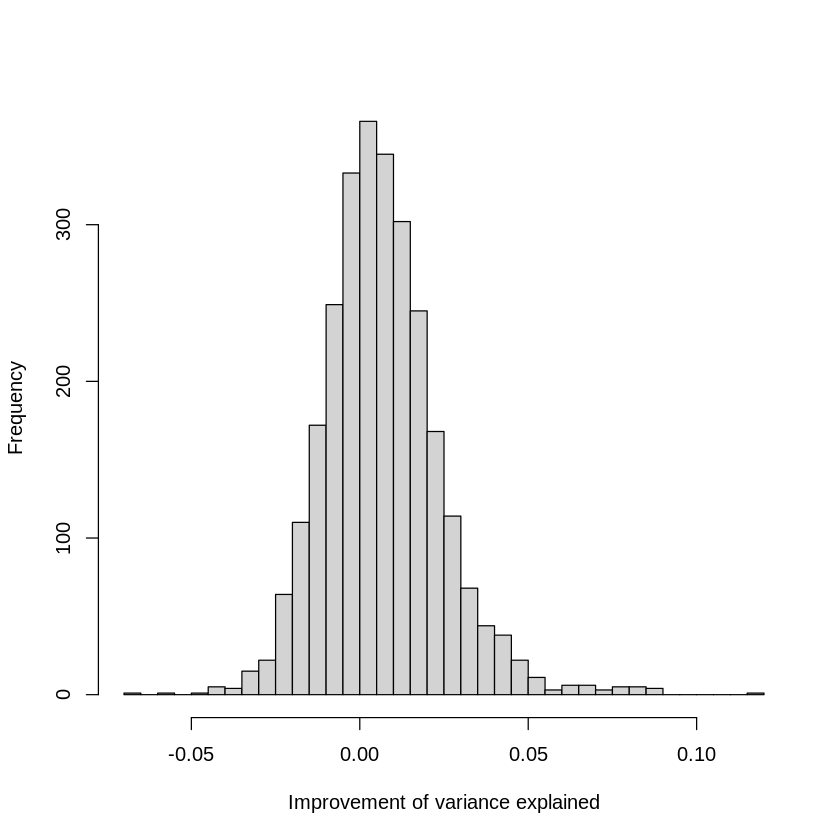

In [151]:
vae.improved = unlist(vae.list) - vae.baseline
hist(vae.improved,breaks =50,main = "",xlab = "Improvement of variance explained")

In [ ]:
hist(unlist(LR.list),freq = F)
lines(density(rchisq(1e5,1)),lwd=3)

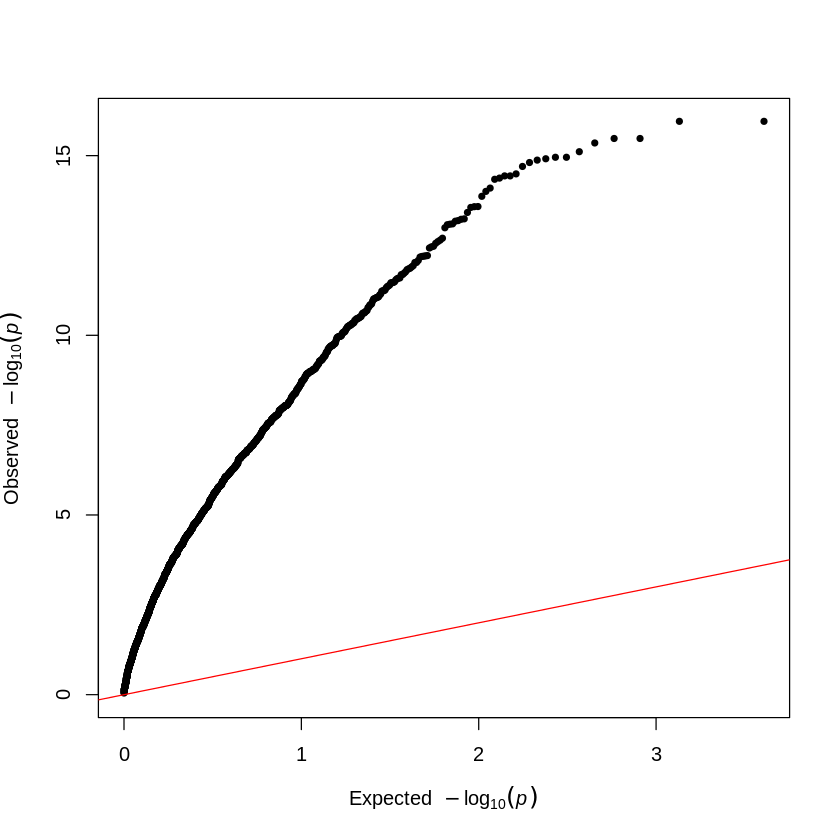

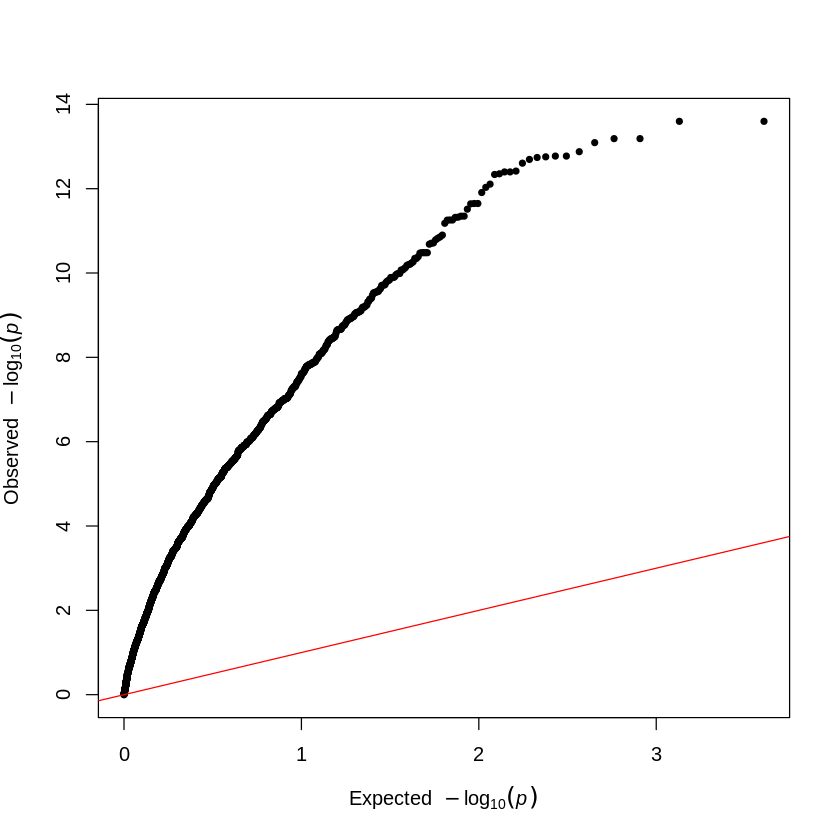

In [152]:
p = 1-pchisq(unlist(LR.list),1)
p.adj = p.adjust(p,"BH")
qqman::qq(p)
qqman::qq(p.adj)

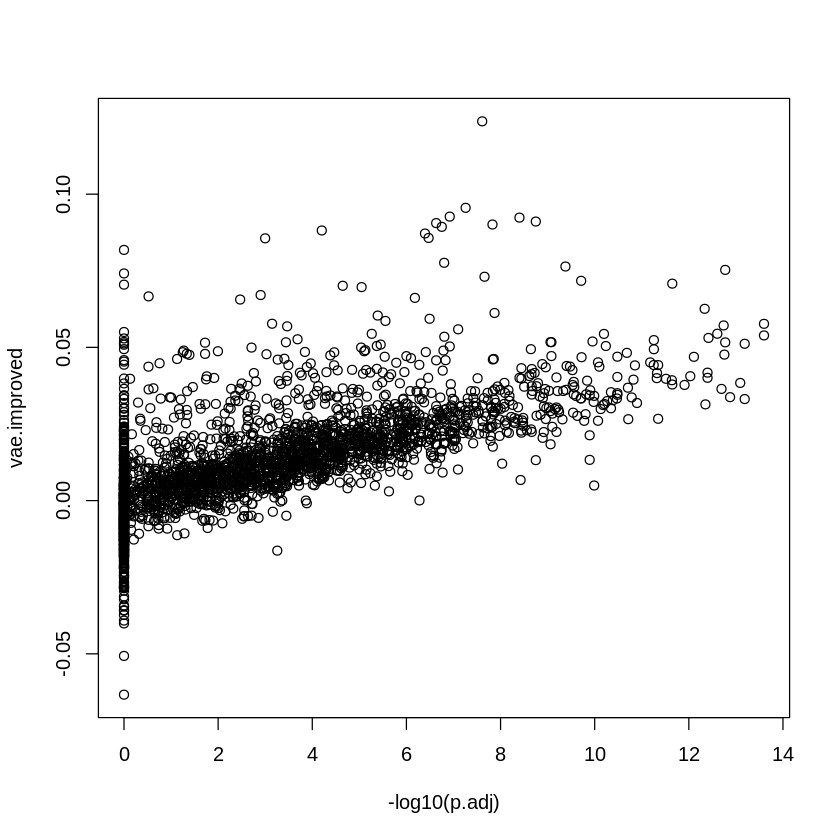

In [119]:
plot(-log10(p.adj),vae.improved)

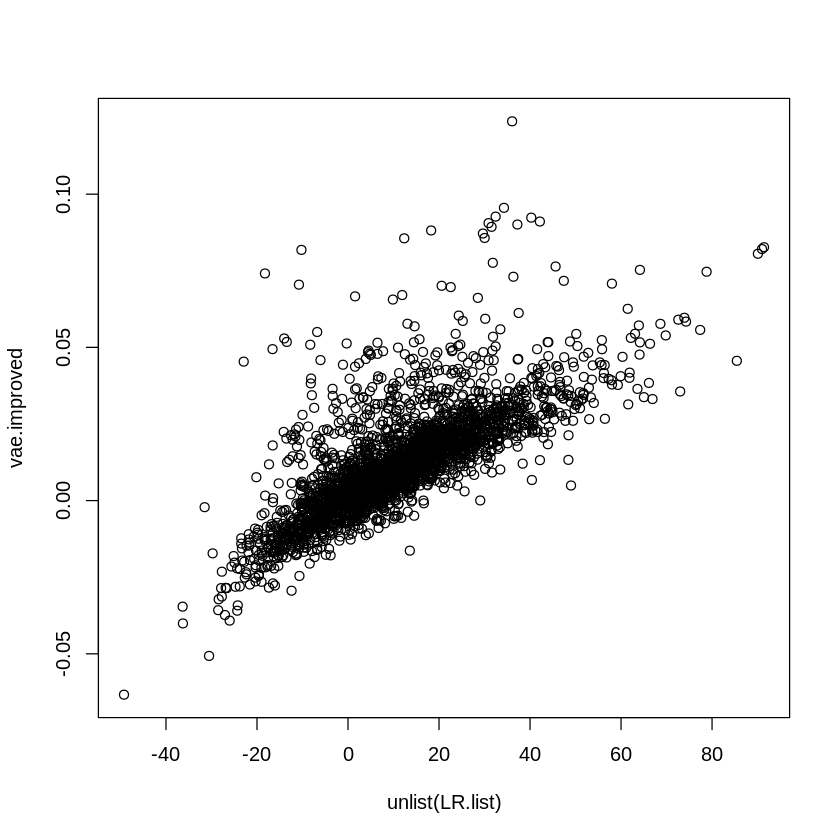

In [120]:
plot(unlist(LR.list),vae.improved)

In [121]:
out = data.frame(gene = names(p),LR = unlist(LR.list),p = p, improvedVAE = vae.improved)

In [122]:
head(out)

,gene,LR,p,improvedVAE
,<chr>,<dbl>,<dbl>,<dbl>
Zm00001eb000080_T001,Zm00001eb000080_T001,-13.6678535,1.000000e+00,-0.008202375
Zm00001eb000150_T001,Zm00001eb000150_T001,47.5038206,5.489720e-12,0.046792671
Zm00001eb000180_T001,Zm00001eb000180_T001,-6.9380979,1.000000e+00,0.015077755
Zm00001eb000360_T001,Zm00001eb000360_T001,-19.7605665,1.000000e+00,-0.009540554
Zm00001eb000460_T001,Zm00001eb000460_T001,0.4677777,4.940113e-01,0.011969180
Zm00001eb000490_T001,Zm00001eb000490_T001,2.4231244,1.195563e-01,0.015896906


In [123]:
write.table(out,"/workdir/hackathon_202309/output/randomEffect_LRT_ePC.txt")

In [274]:
testGene = intersect(names(ModelI.list),names(K.gene.ML.list2))
ModelII.list2 = mclapply(testGene,function(x){
#     idx = intersect(pheno[,1],rownames(x))
    ModelII = BGLR(pheno[idx,2],response_type= "gaussian",nIter = 1e4,burnIn = 5e3,verbose = F,
               ETA=list(Kn = list(K = data.matrix(K.neutral.ML.list2[[x]][idx,idx]),model="RKHS"), 
                        Kg = list(K = data.matrix(K.gene.ML.list2[[x]][idx,idx]),model="RKHS")))
    return(ModelII)               
},mc.cores = 30)


In [275]:
names(ModelII.list2) = testGene

In [276]:
vae.list2 = mclapply(ModelII.list2,function(x) (x$ETA$Kn$varU+x$ETA$Kg$varU)/(x$ETA$Kn$varU+x$ETA$Kg$varU+x$varE),
                    mc.cores = 40)

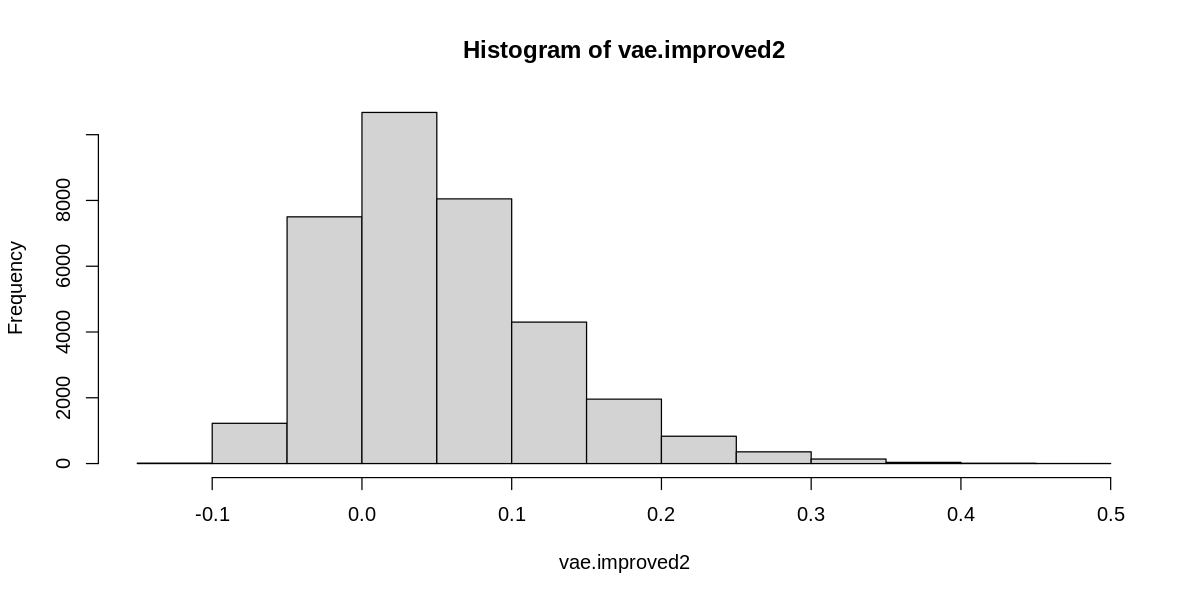

In [277]:
vae.improved2 = unlist(vae.list2[testGene]) - unlist(vae.baseline.list[testGene])
hist(vae.improved2)

In [278]:
LR.list2 = mclapply(testGene,function(x) 2*(ModelII.list2[[x]]$fit$logLikAtPostMean-ModelI.list[[x]]$fit$logLikAtPostMean),mc.cores = 40)

In [279]:
names(LR.list2) = testGene

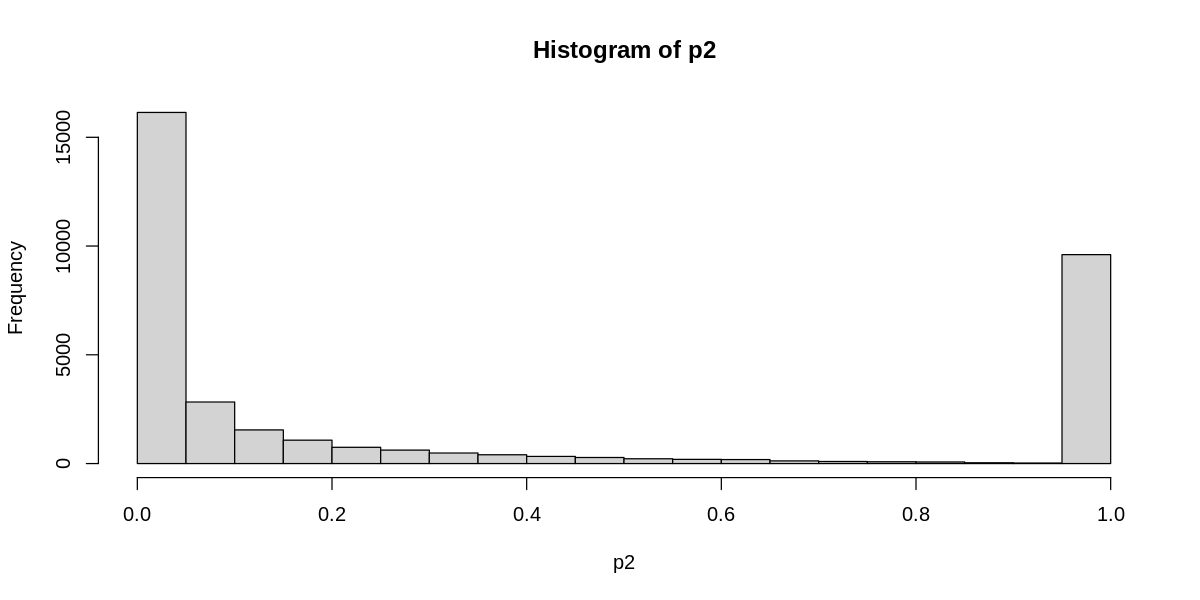

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.000000 0.007422 0.071057 0.340903 1.000000 1.000000 

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0000925 0.0296837 0.1421070 0.3852346 1.0000000 1.0000000 

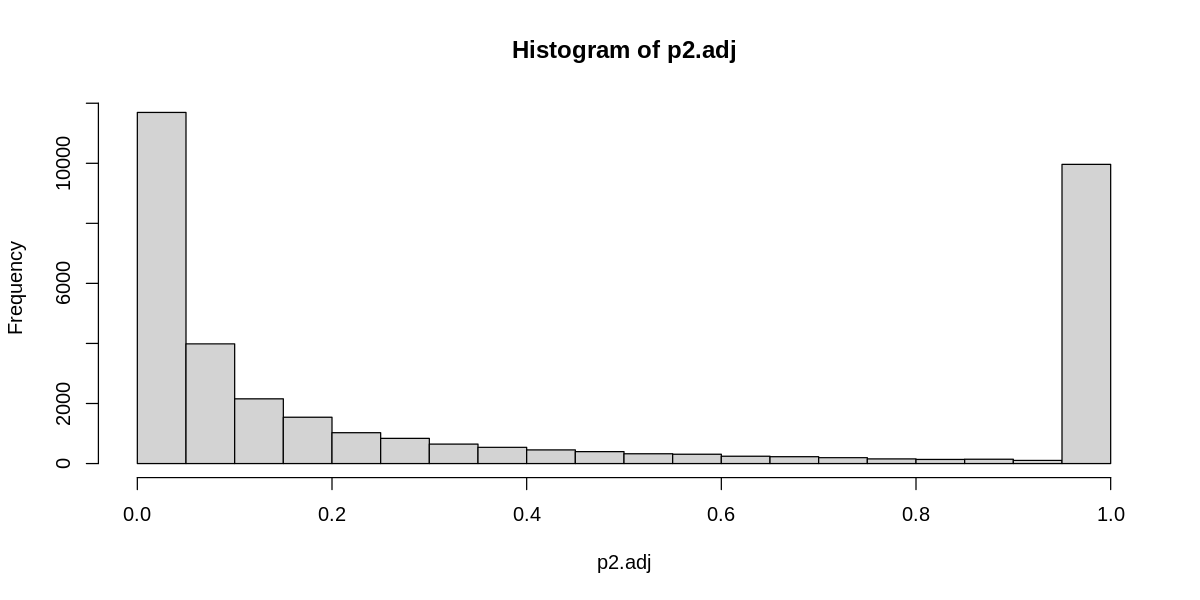

In [280]:
p2 = 1-pchisq(unlist(LR.list2),1)
p2.adj = p.adjust(p2,"BH")
hist(p2)
hist(p2.adj)
summary(p2)
summary(p2.adj)


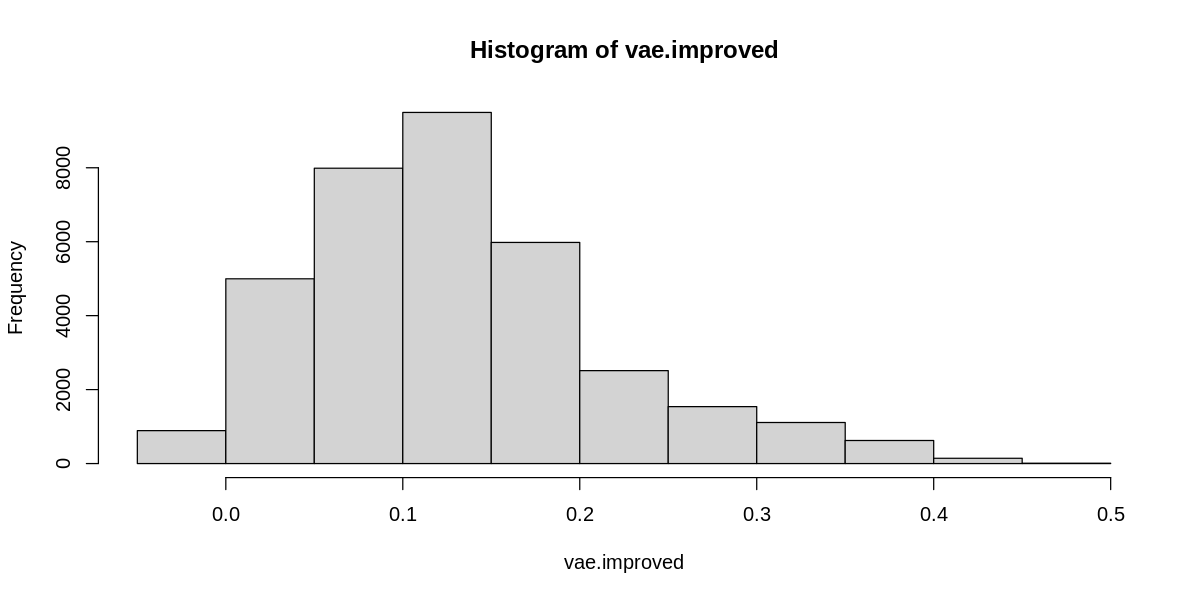

In [204]:
vae.improved = unlist(vae.list) - vae.baseline
hist(vae.improved)

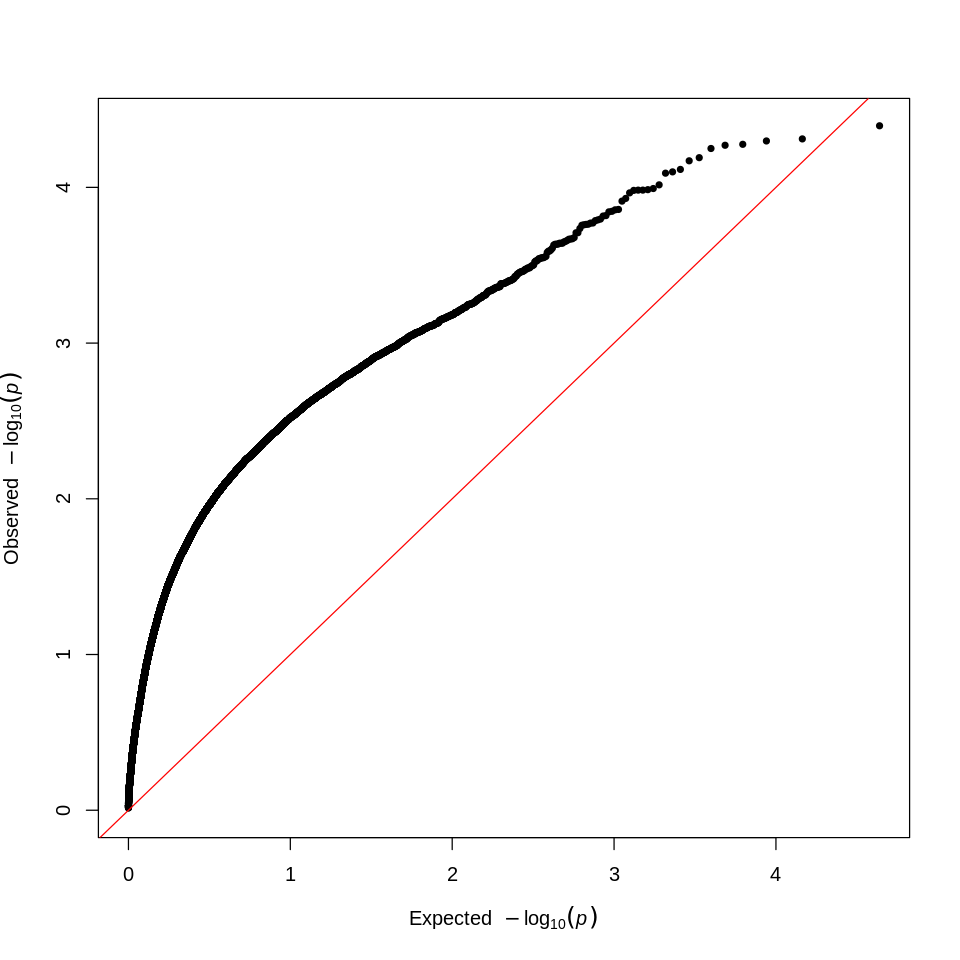

In [214]:
library(qqman)
options(repr.plot.width=8, repr.plot.height=8)
qq(p)

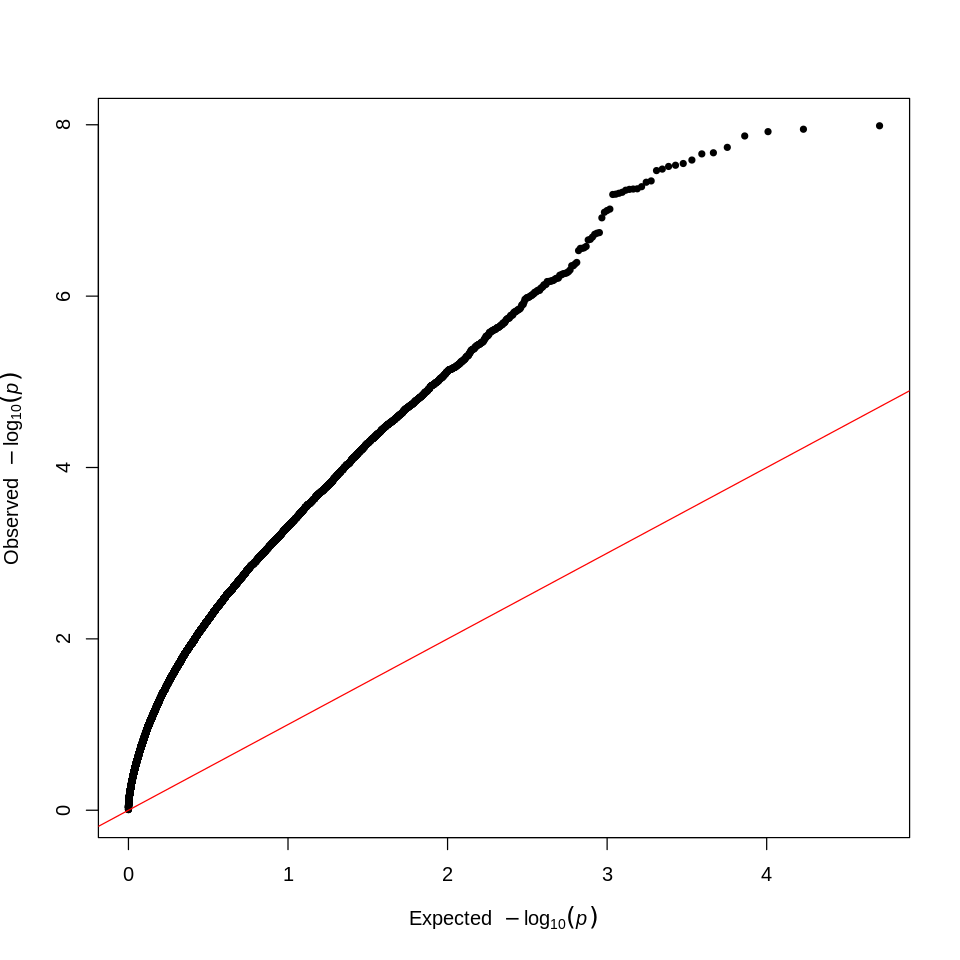

In [281]:
options(repr.plot.width=8, repr.plot.height=8)
qq(p2)

In [163]:
ModelI$fit$DIC
ModelII.list[[1]]$fit$DIC

[1] 334.5393

[1] 330.2328

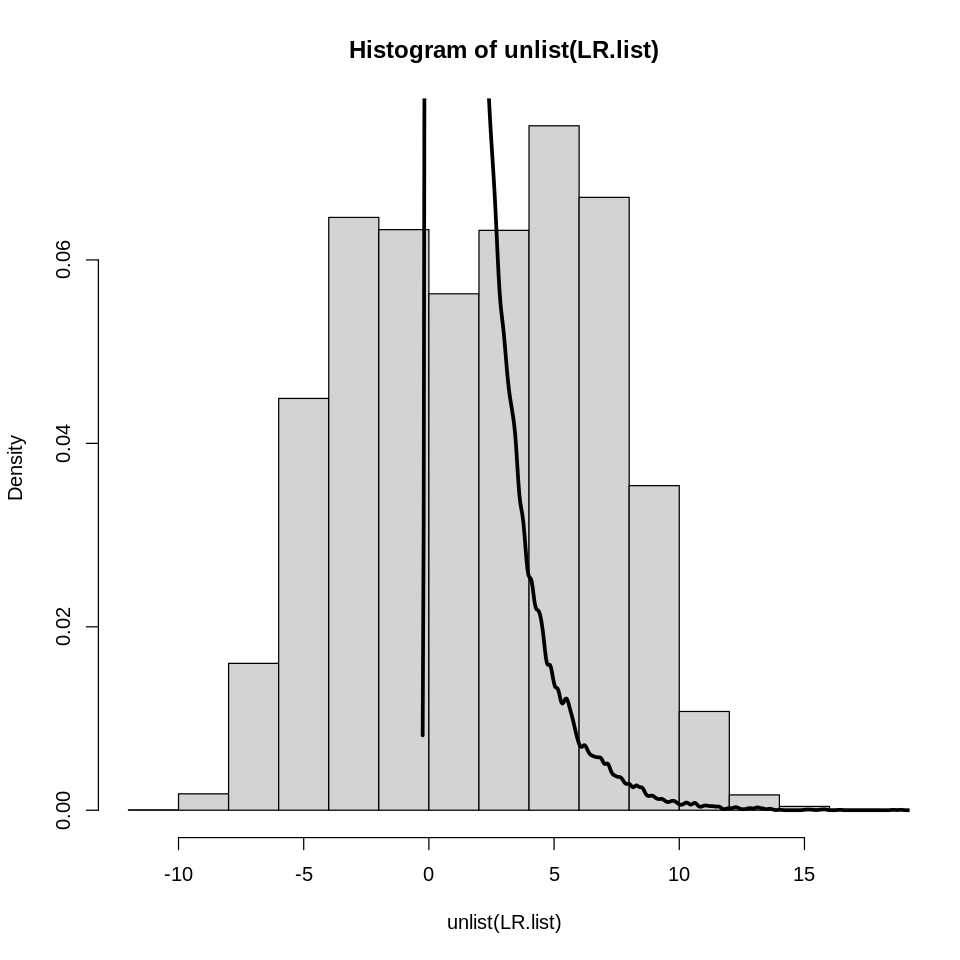

In [207]:
hist(unlist(LR.list),freq = F)
lines(density(rchisq(1e5,1)),lwd=3)

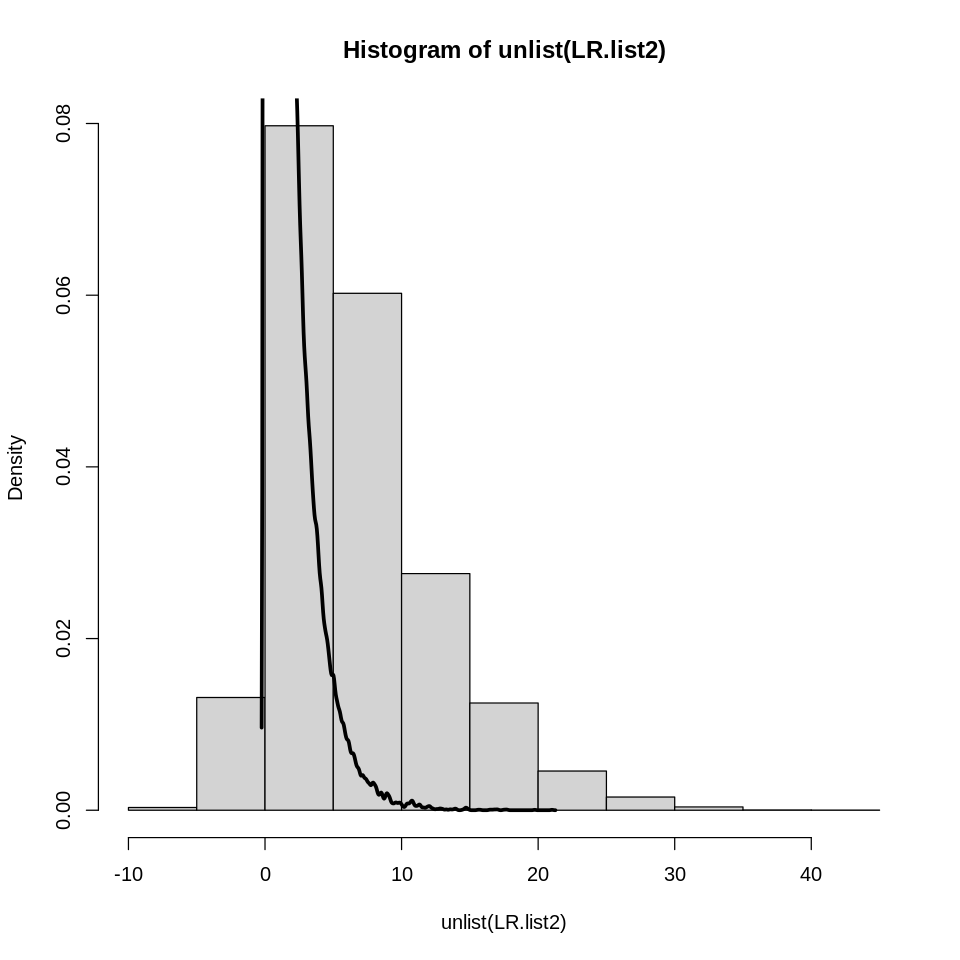

In [253]:
hist(unlist(LR.list2),freq = F)
lines(density(rchisq(1e5,1)),lwd=3)

[1] 0.2205562

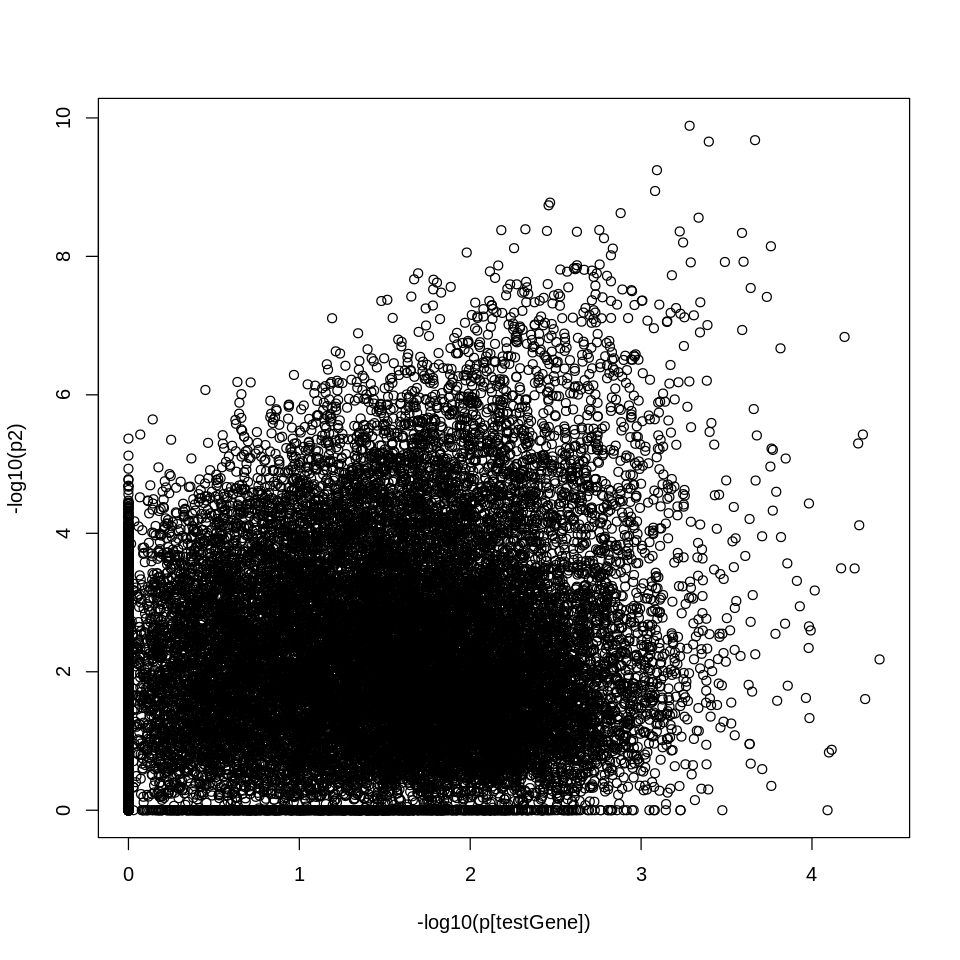

In [257]:
plot(-log10(p[testGene]),-log10(p2))
cor(p[testGene],p2)

In [135]:
dim(pheno)

[1] 35  4

In [177]:
gff=read.delim("/workdir/sh2246/p_evolBNI/data/Pvaginatum_672_v3.1.gene_exons_modified_sorted2.gff3",header = F)
gff_genePos=gff[gff$V3=="mRNA",]
rownames(gff_genePos)=gsub("ID=","",strsplit2(gff_genePos$V9,";")[,1])

In [178]:
head(gff_genePos)

,V1,V2,V3,V4,V5,V6,V7,V8,V9
,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>
Pavag01G000100.1,Chr01,phytozomev13,mRNA,172695,173874,.,-,.,ID=Pavag01G000100.1;Name=Pavag01G000100.1;pacid=50356380;longest=1;Parent=Pavag01G000100
Pavag01G000200.1,Chr01,phytozomev13,mRNA,193720,198422,.,-,.,ID=Pavag01G000200.1;Name=Pavag01G000200.1;pacid=50353290;longest=1;Parent=Pavag01G000200
Pavag01G000200.2,Chr01,phytozomev13,mRNA,193720,198422,.,-,.,ID=Pavag01G000200.2;Name=Pavag01G000200.2;pacid=50353291;longest=0;Parent=Pavag01G000200
Pavag01G000300.1,Chr01,phytozomev13,mRNA,199474,200321,.,+,.,ID=Pavag01G000300.1;Name=Pavag01G000300.1;pacid=50358427;longest=1;Parent=Pavag01G000300
Pavag01G000300.2,Chr01,phytozomev13,mRNA,199474,200321,.,+,.,ID=Pavag01G000300.2;Name=Pavag01G000300.2;pacid=50358428;longest=0;Parent=Pavag01G000300
Pavag01G000400.1,Chr01,phytozomev13,mRNA,201734,202057,.,-,.,ID=Pavag01G000400.1;Name=Pavag01G000400.1;pacid=50353828;longest=1;Parent=Pavag01G000400


In [259]:
LRT_out = data.frame(Chr=as.numeric(gsub("Chr","",gff_genePos[names(p),]$V1)),
                     BP=gff_genePos[names(p),]$V4,Gene = names(p),
                     lnLR=unlist(LR.list),P=p)

In [263]:
LRT_out2 = data.frame(Chr=as.numeric(gsub("Chr","",gff_genePos[names(p2),]$V1)),
                     BP=gff_genePos[names(p2),]$V4,Gene = names(p2),
                     lnLR=unlist(LR.list2),P=p2)

In [209]:
head(LRT_out)

,Chr,BP,Gene,lnLR,P
,<dbl>,<int>,<chr>,<dbl>,<dbl>
1,1,172695,Pavag01G000100.1,9.086763,0.0025746619
2,1,193720,Pavag01G000200.1,-3.629150,1.0000000000
3,1,193720,Pavag01G000200.2,-4.077005,1.0000000000
4,1,237304,Pavag01G000500.1,7.172342,0.0074036042
5,1,237304,Pavag01G000500.2,11.169152,0.0008316862
6,1,237304,Pavag01G000500.3,8.030994,0.0045983609


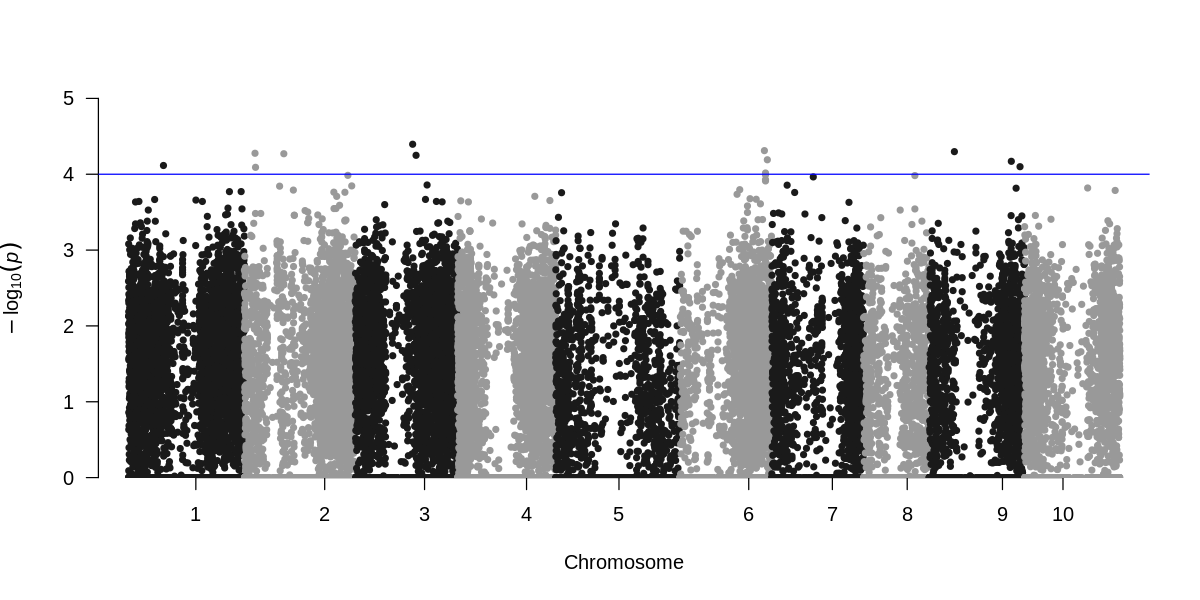

In [210]:
options(repr.plot.width=10, repr.plot.height=5)
manhattan(na.omit(LRT_out),chr = "Chr",bp = "BP",p = "P",snp = "Gene",logp = T,suggestiveline = 4,genomewideline = F)


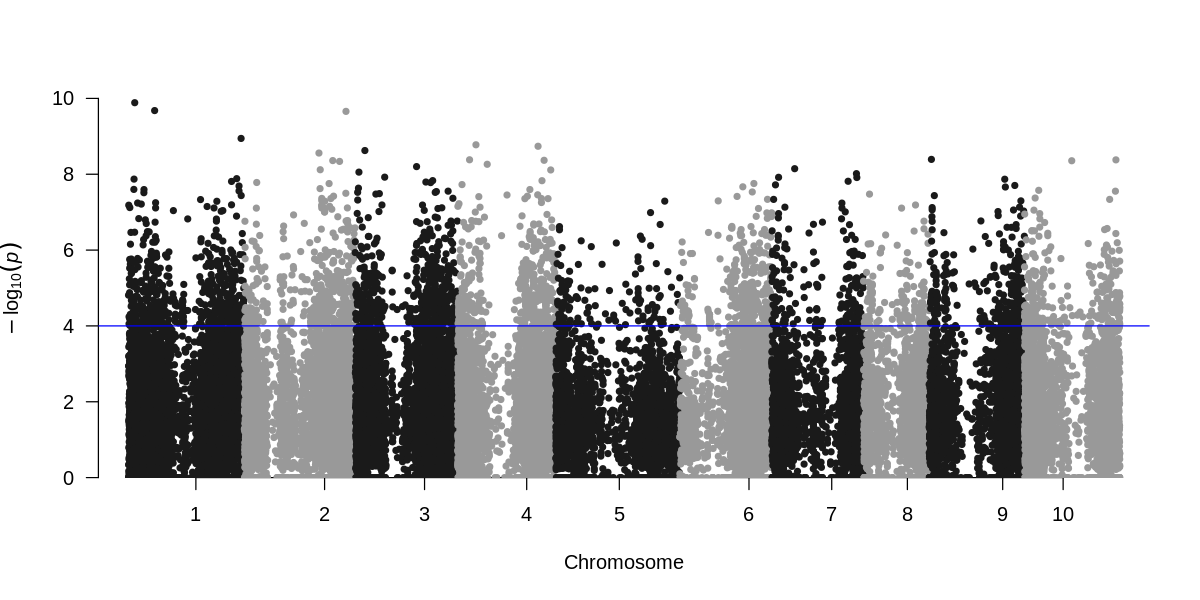

In [264]:
options(repr.plot.width=10, repr.plot.height=5)
manhattan(na.omit(LRT_out2),chr = "Chr",bp = "BP",p = "P",snp = "Gene",logp = T,suggestiveline = 4,genomewideline = F)


In [211]:
head(sort(p),10)

Pavag03G169400.1 Pavag06G250300.1 Pavag09G085300.1 Pavag02G052500.1 
    4.022458e-05     4.883882e-05     5.035072e-05     5.290471e-05 
Pavag02G114600.1 Pavag03G176900.1 Pavag06G270300.1 Pavag09G184700.1 
    5.365347e-05     5.628070e-05     6.445973e-05     6.752606e-05 
Pavag01G205500.1 Pavag09G237100.1 
    7.668723e-05     7.952924e-05

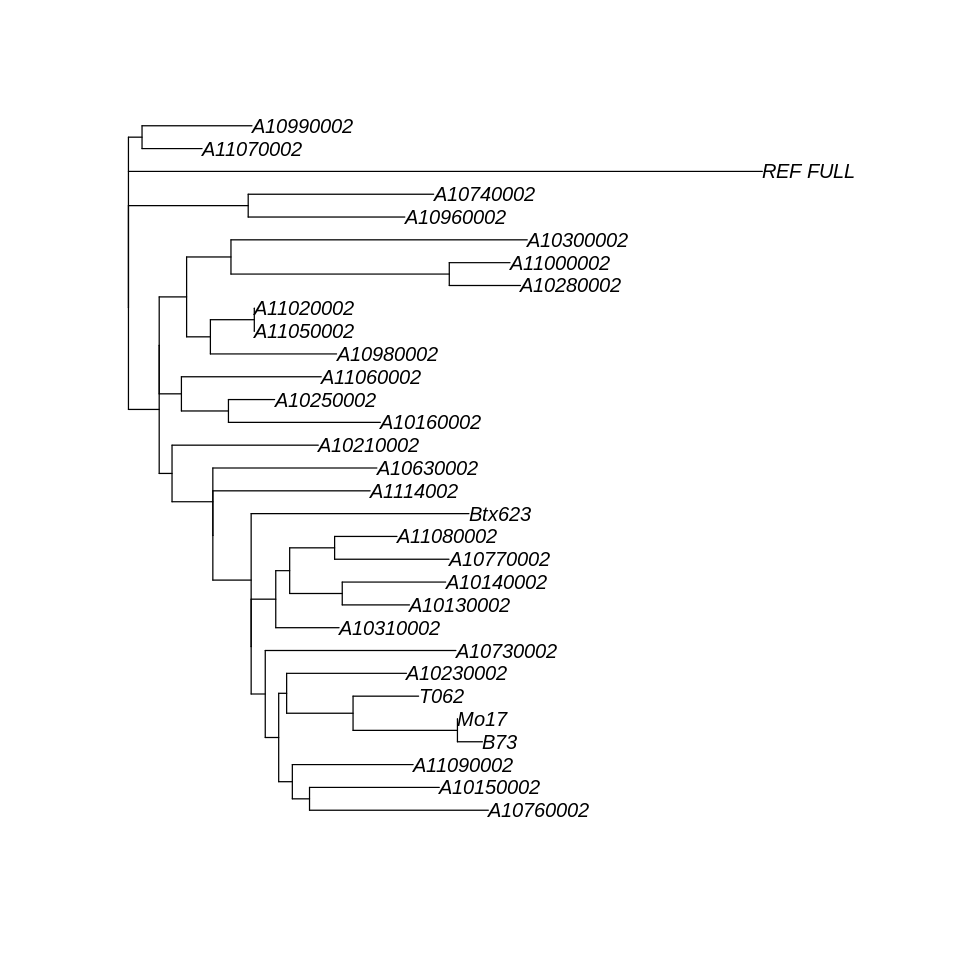

In [216]:
plot(gTre.renamed[["Pavag09G085300.1"]])